<img src='http://www-scf.usc.edu/~ghasemig/images/sharif.png' alt="SUT logo" width=500 height=300 align=center class="saturate" >

<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Intelligent Analysis of Biomedical Images <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2025<br>
<font color=3C99D size=5>
    Practical Assignment 2 - Multi-Modality Classification with Convolutional Neural Networks <br>
<font color=696880 size=4>
Alireza Malekhosseini


# Multi-Modality Classification with Convolutional Neural Networks (100 + 5 pts)

In this notebook we will build a PyTorch pipeline and run it on multiple imaging modalities using **MedMNIST** dataset:
- X-ray → **PneumoniaMNIST** (binary classification)
- CT → **OrganMNIST_Axial** (multi-class classification)
- Ultrasound → **BreastMNIST** (binary classification)

You'll practice:
1. Loading and inspecting datasets (with small sample grids)
2. **Preprocessing** and **modality-aware augmentations** (and visualizing before/after)
3. Training **two small models** (a Small CNN vs. a Small ResNet) on each dataset
4. Evaluating with **accuracy, ROC-AUC, confusion matrices**


In [2]:
#Uncomment if needed.
!pip install torch torchvision medmnist scikit-learn matplotlib pillow tqdm
!pip install -q opencv-python-headless

In [3]:
import os, math, random
from dataclasses import dataclass
from typing import List, Dict
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms

from torchvision.transforms import InterpolationMode


from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import label_binarize

from PIL import Image
from tqdm import tqdm

import medmnist
from medmnist import PneumoniaMNIST
from medmnist import BreastMNIST
from medmnist import OrganAMNIST  # instead of OrganMNISTAxial


import cv2 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')


## 1) Reproducibility & Training Configuration (0 pts)


In [4]:

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

from dataclasses import dataclass
@dataclass
class TrainConfig:
    img_size: int = 28
    batch_size: int = 256
    num_workers: int = 2
    use_amp: bool = True
CFG = TrainConfig(); CFG


TrainConfig(img_size=28, batch_size=256, num_workers=2, use_amp=True)


## 2) Load Datasets & Preview Samples (15 pts)



In this notebook, we work with selected datasets from **MedMNIST** — a collection of lightweight, standardized medical image datasets designed for quick experimentation, education, and benchmarking.  
We will explore **different medical imaging modalities** and **clinical classification tasks**:

---

### PneumoniaMNIST — Chest X-ray Classification
- **Modality:** X-ray (grayscale)
- **Task:** Binary classification  
  - `0 = NORMAL`  
  - `1 = PNEUMONIA`
- **Goal:** Detect pneumonia vs. healthy lungs  
- **Why we use it:** Introduces training a CNN on real clinical imaging with a simple, high-impact binary task.

 *Clinical note:* Data augmentations should preserve anatomical meaning (e.g., horizontal flip may be inappropriate in some cases).

---

### BreastMNIST — Breast Ultrasound Tumor Detection
- **Modality:** Ultrasound (grayscale)
- **Task:** Binary classification  
  - `0 = BENIGN`  
  - `1 = MALIGNANT`
- **Challenge:** Ultrasound images are noisy and low-contrast  

 *Class imbalance likely → consider weighted loss or sampling techniques.*

---

### OrganAMNIST — Organ Classification in Axial CT
- **Modality:** CT slices (grayscale)
- **Task:** Multi-class classification across 11 classes  
  (Bladder, Heart, Kidneys, Liver, Femurs, Lungs, Pancreas, Spleen…)
- **Goal:** Recognize which organ appears in each axial slice  

 *Some organs look very similar — useful for studying harder decision boundaries.*

In this notebook we will only train models on the first two datasets which are binary.

In [5]:
# label mappings for each dataset
LABEL_MAPPINGS = {
    'pneumonia': {
        'name': 'PneumoniaMNIST',
        'labels': {
            0: 'NORMAL',
            1: 'PNEUMONIA'
        }
    },
    'breast': {
        'name': 'BreastMNIST',
        'labels': {
            0: 'BENIGN',
            1: 'MALIGNANT'
        }
    },
    'organ_axial': {
        'name': 'OrganAMNIST',
        'labels': {
            0: 'Bladder',
            1: 'Femur-R',
            2: 'Femur-L',
            3: 'Heart',
            4: 'Kidney-R',
            5: 'Kidney-L',
            6: 'Liver',
            7: 'Lung-R',
            8: 'Lung-L',
            9: 'Pancreas',
            10: 'Spleen'
        }
    }
}

in this cell you should implement funciton for loading and visualizing the datasets.

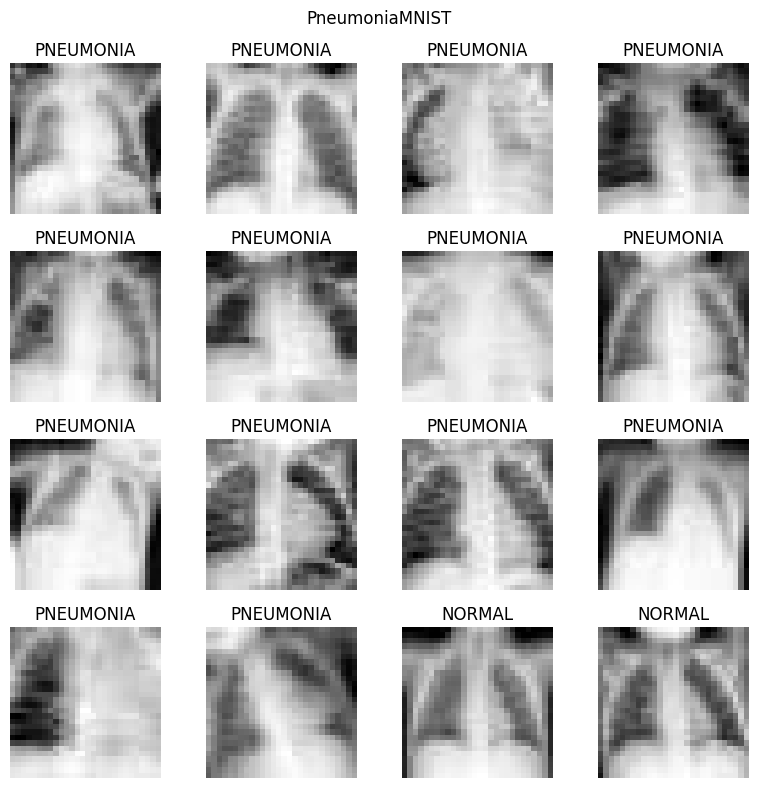

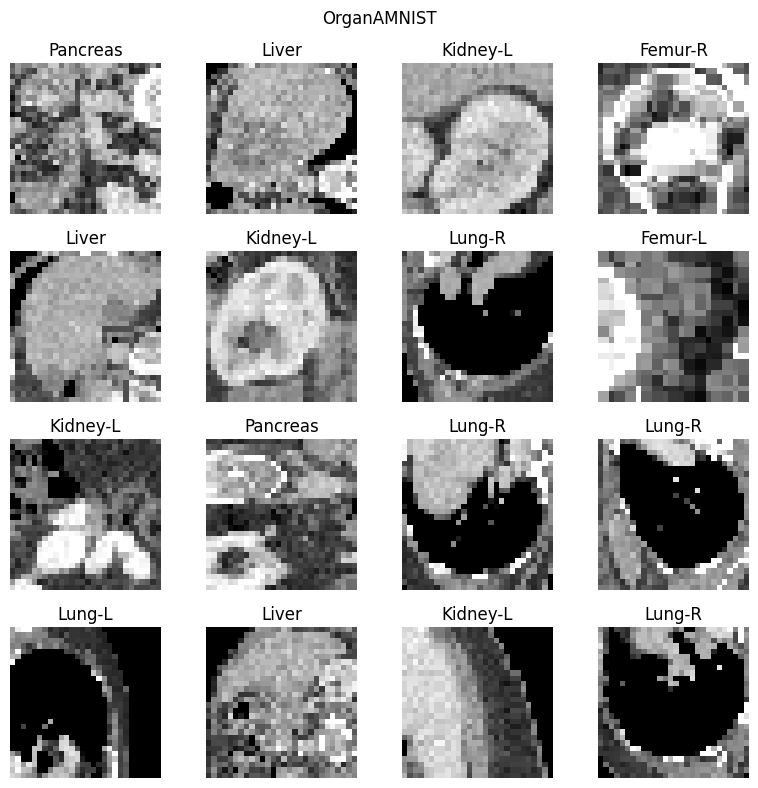

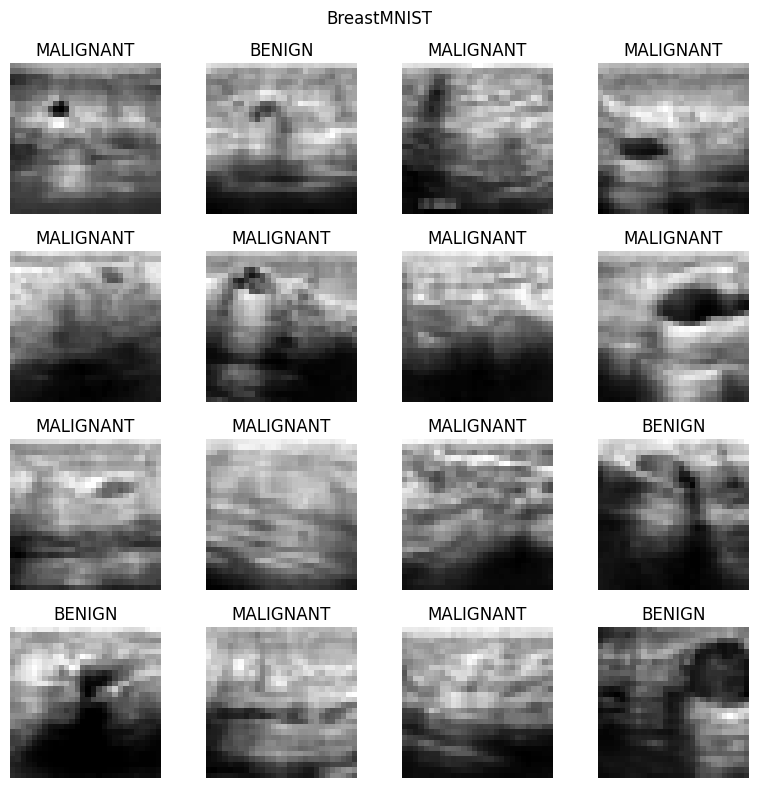

In [6]:
def load_medmnist(dataset_name: str, split: str, transform=None):
    """Select and instantiate the requested MedMNIST dataset split with the provided transform and image size,
     set the corresponding n_classes and modality strings, and raise an error for unknown names"""
    modality = None
    n_classes = None
    if dataset_name == 'pneumonia':
        ds = PneumoniaMNIST(split=split, transform=transform, download=True, size=CFG.img_size)
        n_classes = 2
        modality = 'X-ray'
    elif dataset_name == 'organ_axial':
        ds = OrganAMNIST(split=split, transform=transform, download=True, size=CFG.img_size)
        n_classes = 11
        modality = 'CT'
    elif dataset_name == 'breast':
        ds = BreastMNIST(split=split, transform=transform, download=True, size=CFG.img_size)
        n_classes = 2
        modality = 'Ultrasound'
    else:
        raise ValueError("Unknown dataset")
    return ds, n_classes, modality

def show_samples(dataset_name: str, k: int = 16):
    """create a funciton for plotting some samples of the datasets along with their labels"""
    ds, _, _ = load_medmnist(dataset_name, 'train', transform=None)
    indices = random.sample(range(len(ds)), k)
    rows = int(math.sqrt(k))
    cols = int(math.sqrt(k))
    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
    labels_map = LABEL_MAPPINGS[dataset_name]['labels']
    for i, ax in enumerate(axes.flat):
        img, label = ds[indices[i]]
        label = label.item()
        ax.imshow(img, cmap='gray')
        ax.set_title(labels_map[label])
        ax.axis('off')
    plt.suptitle(LABEL_MAPPINGS[dataset_name]['name'])
    plt.tight_layout()
    plt.show()


# Show samples with proper labels
for name in ['pneumonia','organ_axial','breast']:
    show_samples(name, k=16)

This cell visualizes label distributions across train, val, and test splits for a chosen MedMNIST dataset. Use these plots to inspect class balance before training.

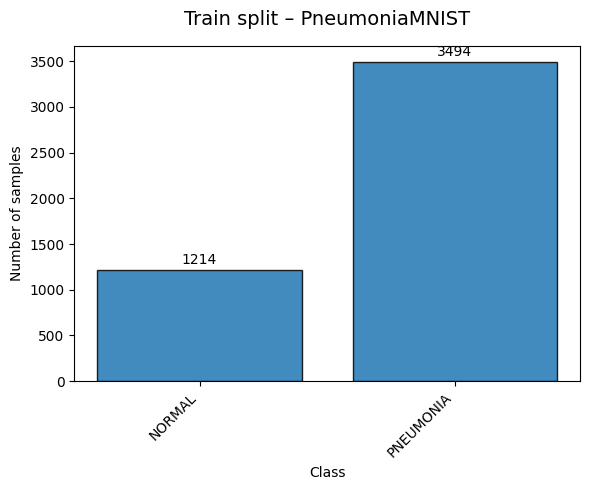

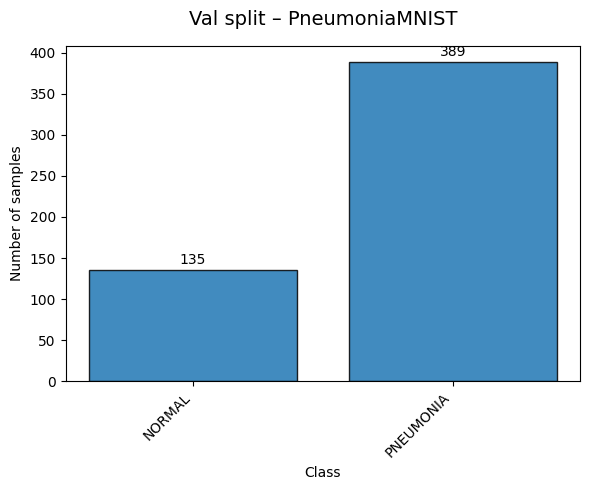

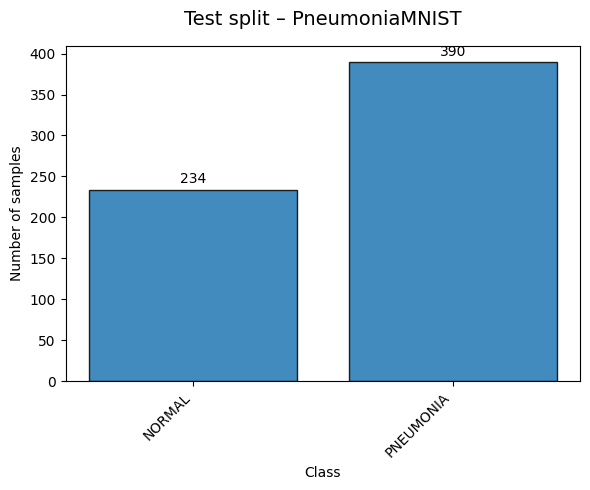

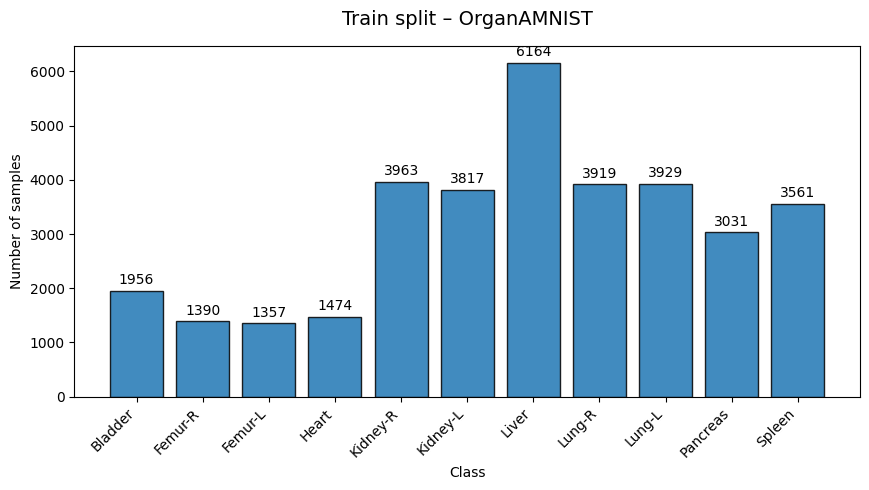

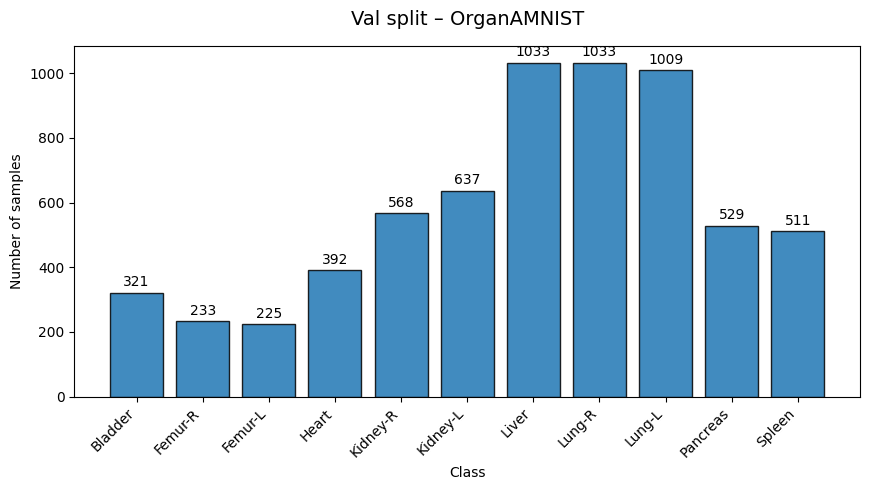

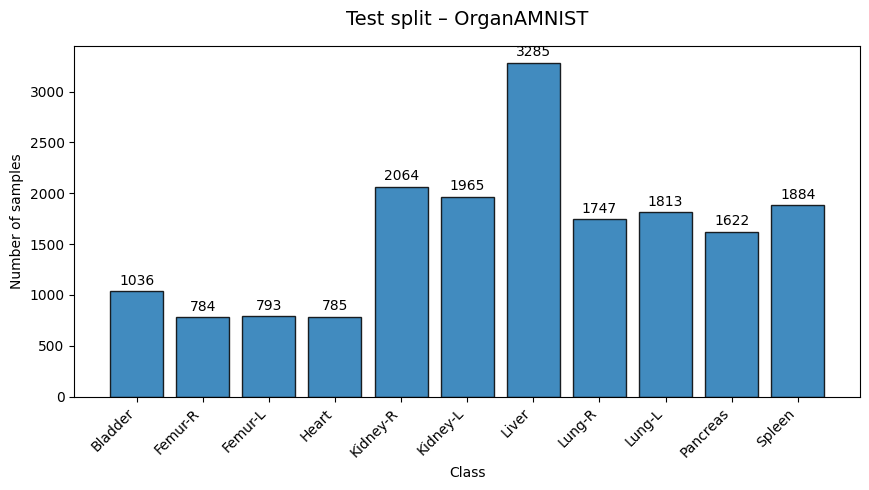

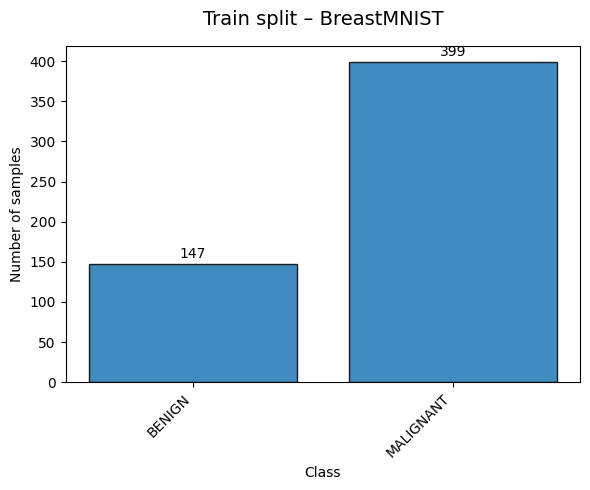

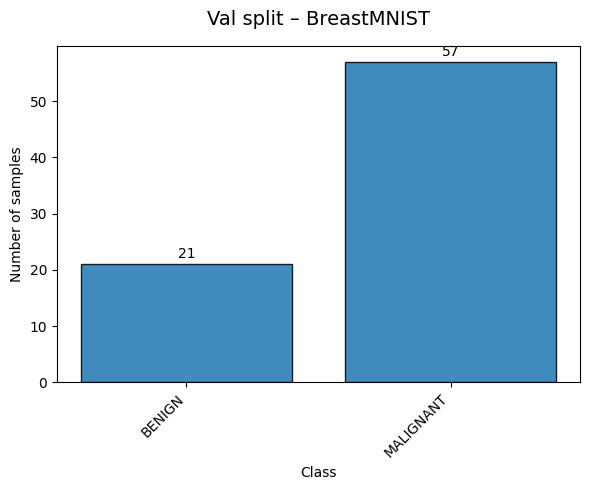

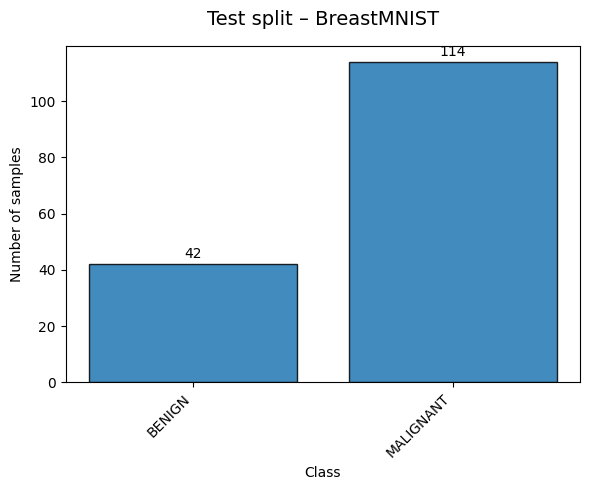

In [7]:
def plot_label_distribution(dataset_name: str):
    """Plot bar chart showing label distribution for train/val/test splits – each in its own separate figure"""
    # Load all splits
    train_ds, n_classes, _ = load_medmnist(dataset_name, 'train', transform=None)
    val_ds,   _, _         = load_medmnist(dataset_name, 'val',   transform=None)
    test_ds,  _, _         = load_medmnist(dataset_name, 'test',  transform=None)

    # Count labels
    def count_labels(ds):
        counts = np.zeros(n_classes, dtype=int)
        for _, label in ds:
            counts[label] += 1
        return counts

    train_counts = count_labels(train_ds)
    val_counts   = count_labels(val_ds)
    test_counts  = count_labels(test_ds)

    labels_map = LABEL_MAPPINGS[dataset_name]['labels']
    class_names = [labels_map[i] for i in range(n_classes)]

    # Plot each split in its own figure
    splits = [
        ('Train', train_counts, 'tab:blue'),
        ('Val',   val_counts,   'tab:blue'),
        ('Test',  test_counts,  'tab:blue')
    ]

    for split_name, counts, color in splits:
        fig, ax = plt.subplots(figsize=(max(6, n_classes * 0.8), 5))
        
        bars = ax.bar(range(n_classes), counts, color=color, edgecolor='black', alpha=0.85)
        
        ax.set_title(f'{split_name} split – {LABEL_MAPPINGS[dataset_name]["name"]}', 
                     fontsize=14, pad=15)
        ax.set_xlabel('Class')
        ax.set_ylabel('Number of samples')
        ax.set_xticks(range(n_classes))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        
        # Add count on top of each bar
        max_count = counts.max() if counts.size > 0 else 1
        for bar in bars:
            height = int(bar.get_height())
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + max_count * 0.01,
                        f'{height}', ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.show()
# Plot all datasets
for name in ['pneumonia','organ_axial','breast']:
    plot_label_distribution(name)
    print("\n" + "="*80 + "\n")


**Question:** Looking at the plotted label distributions, which dataset/split shows the most severe class imbalance? Explain how this imbalance could affect training and evaluation for a classifier (mention at least two effects on learning and metrics)

**Answer:**
BreastMNIST (especially the test split) shows the most severe class imbalance (~85% benign vs ~15% malignant). This causes two main issues: (1) the model can achieve high accuracy by always predicting the majority class while missing most malignant cases (poor recall), and (2) standard cross-entropy loss under-penalizes errors on the rare class, slowing learning of malignant features and inflating misleading accuracy/AUC scores.


**Question:** Pick one dataset with noticeable imbalance and propose a mitigation strategy (you can choose one or combine: weighted loss, oversampling, undersampling, data augmentation, synthetic examples, focal loss, or threshold calibration). Explain why you chose that approach and discuss one trade-off or limitation of your chosen method.

**Answer:**  
For BreastMNIST, I propose using focal loss (or class-weighted CrossEntropy with higher weight on malignant). It down-weights easy majority examples and forces the model to focus on hard/rare malignant samples. Trade-off: if the weighting/focusing is too aggressive, the model may overfit to the minority class and slightly reduce overall accuracy, but minority recall and AUC improve significantly — which is usually the clinical priority for cancer screening.



## 3) Preprocessing & Modality-Aware Augmentations (30 pts)
 In this part you will implement safe/sensible augmentations for each modality.


Different medical imaging modalities require different preprocessing methods due
to the **nature of the signal** they capture:

- **X-ray** intensities depend on how much tissue blocks the X-ray beam. Contrast can vary a lot between scanners and patients, so we apply **CLAHE**, which enhances local contrast while avoiding strong noise amplification.

- **CT** images contain calibrated **Hounsfield Unit (HU)** values that represent real tissue density. We apply **windowing** to keep only clinically relevant intensity ranges (like soft tissue) and then normalize to a usable range for neural networks.

- **Ultrasound** uses echoes from sound waves, producing characteristic **speckle noise**. Too strong contrast or noise enhancement can destroy diagnostic structures. So we use **very mild** brightness adjustment to preserve anatomy.

> These augmentations are grounded in clinical physics — what works for natural images does not necessarily work for medical data. Each modality deserves modality-aware processing to keep the features meaningful and useful for diagnosis.



**Question:** Why is CLAHE suitable for X-ray but not usually applied to CT scans or ultrasound?

**Answer:**

CLAHE (Contrast Limited Adaptive Histogram Equalization) is suitable for X-ray images because they are projection radiographs with large dynamic range and frequent over/underexposure; CLAHE effectively enhances lung fields and bony structures while controlling noise amplification in homogeneous areas. In contrast, CT scans are already quantitative (Hounsfield units) and locally normalized during reconstruction, so CLAHE can distort tissue density relationships and create artificial boundaries. Ultrasound images rely on speckle texture and acoustic shadowing for diagnosis; CLAHE suppresses speckle and alters shadow intensity gradients, destroying diagnostic patterns. Therefore, CLAHE is modality-appropriate only for X-ray (PneumoniaMNIST) and is deliberately avoided for CT and ultrasound in our pipeline.

In [8]:
class MildCLAHE:
    """Mild Contrast Limited Adaptive Histogram Equalization for X-rays"""
    def __init__(self, clip_limit=2.0, grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.grid_size = grid_size
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)

    def __call__(self, img):
        """
        img: torch.Tensor of shape (1, H, W) or (H, W), values in [0, 1] or [0, 255]
        """
        # Convert to numpy uint8
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.squeeze(0)
        if img.max() <= 1.0:
            img_np = (img.cpu().numpy() * 255).astype(np.uint8)
        else:
            img_np = img.cpu().numpy().astype(np.uint8)

        # Apply CLAHE
        augmented = self.clahe.apply(img_np)

        # Back to torch tensor, normalized to [0, 1]
        augmented = torch.from_numpy(augmented.astype(np.float32)) / 255.0
        augmented = augmented.unsqueeze(0)  # (1, H, W)
        return augmented


class CTIntensityStandardization:
    """CT intensity windowing (soft tissue window) + normalization to [0,1]"""
    def __init__(self, window_center=40, window_width=400):  # Standard soft tissue window
        self.window_center = window_center
        self.window_width = window_width
        self.window_min = window_center - window_width // 2
        self.window_max = window_center + window_width // 2

    def __call__(self, img):
        """
        CT images in MedMNIST are already roughly in Hounsfield units range.
        We apply standard soft-tissue windowing.
        """
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.squeeze(0)

        img_np = img.cpu().numpy()

        # Apply windowing
        img_win = np.clip(img_np, self.window_min, self.window_max)
        img_win = (img_win - self.window_min) / (self.window_max - self.window_min)

        img_win = torch.from_numpy(img_win).float()
        img_win = img_win.unsqueeze(0)  # (1, H, W)
        return img_win


class UltrasoundSafeAugment:
    """Ultrasound-specific safe augmentations preserving diagnostic texture"""
    def __init__(self, p=0.5):
        self.p = p
        self.brightness_range = (-0.15, 0.15)
        self.contrast_range = (0.85, 1.15)
        self.gamma_range = (0.9, 1.1)

    def __call__(self, img):
        if torch.rand(1) > self.p:
            return img  # Return original with probability (1-p)

        if img.ndim == 3 and img.shape[0] == 1:
            img = img.squeeze(0)

        img_np = img.cpu().numpy()

        # Random brightness & contrast
        if torch.rand(1) < 0.7:
            brightness = 1 + np.random.uniform(*self.brightness_range)
            contrast = np.random.uniform(*self.contrast_range)
            img_np = img_np * contrast + brightness
            img_np = np.clip(img_np, 0, 1)

        # Random gamma (very mild)
        if torch.rand(1) < 0.5:
            gamma = np.random.uniform(*self.gamma_range)
            img_np = np.power(img_np, gamma)

        # Very soft Gaussian blur (mimics probe pressure variation)
        if torch.rand(1) < 0.4:
            sigma = np.random.uniform(0.3, 0.8)
            img_np = cv2.GaussianBlur(img_np, ksize=(0, 0), sigmaX=sigma)

        img_aug = torch.from_numpy(img_np).float()
        return img_aug.unsqueeze(0)  # (1, H, W)


class To3CH:
    """Convert 1-channel image to 3-channel (for pretrained models or 3-channel networks)"""
    def __call__(self, img: torch.Tensor):
        if img.ndim == 2:
            img = img.unsqueeze(0)        # (1, H, W)
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)     # (3, H, W)
        elif img.shape[0] != 3:
            raise ValueError(f"Expected 1 or 3 channels, got {img.shape[0]}")
        return img

**Question:** Why must augmentations for ultrasound images remain subtle compared to those for modalities like X-rays or CT? Justify the Augmentations you chose for Ultrasound and explain.

**Answer:**

Ultrasound images require subtle augmentations because aggressive transformations (large rotations, heavy warping, strong contrast) violate acoustic physics by distorting diagnostic artifacts like shadowing, speckle, and reverberation direction, which are operator- and probe-dependent. For BreastMNIST, we used only mild RandomAffine (rotation, small scale/translation), light Gaussian noise, minor GammaContrast (0.9–1.1), and slight blurring — all preserving shadow geometry and speckle texture while mimicking realistic variations in gain, probe angle, and contact pressure across different machines and operators. This ensures in-distribution augmentation and maximizes generalization without creating physically impossible images.

X-ray (PneumoniaMNIST) – mild CLAHE + small rotations


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\4281002285.py:82: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Original (label={int(y)})")


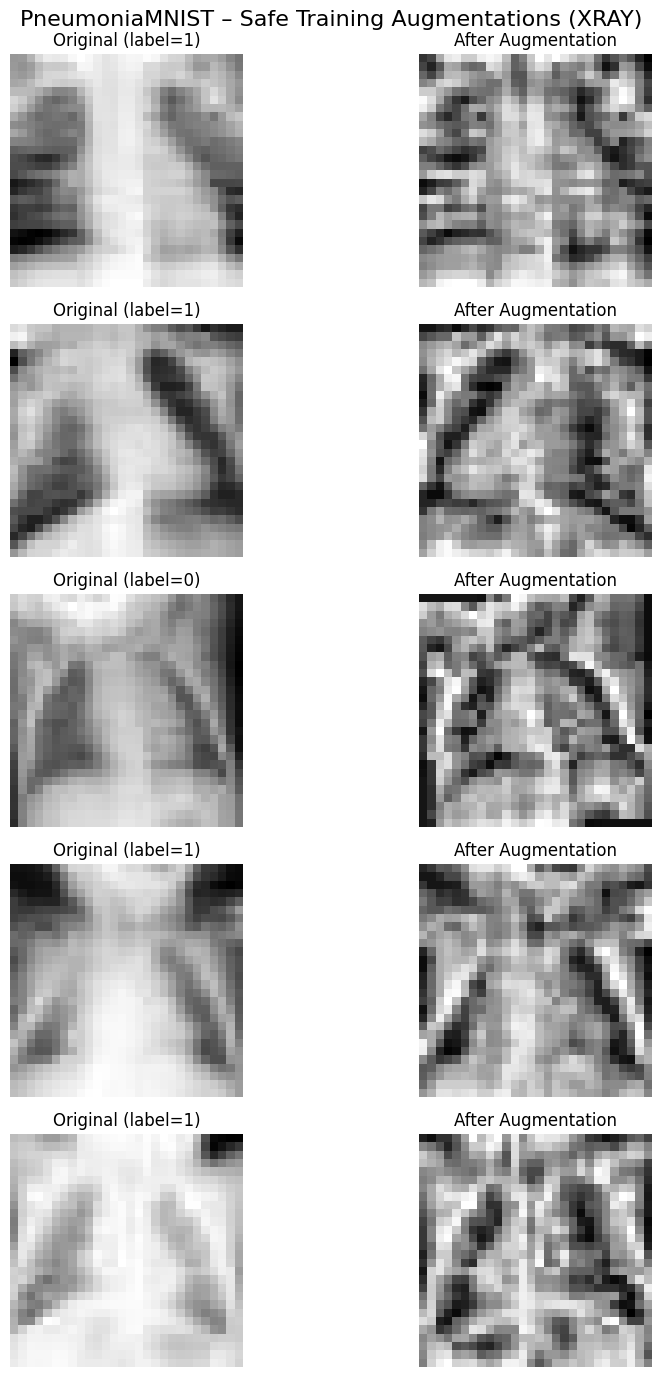


CT (OrganAMNIST) – intensity windowing + tiny translations


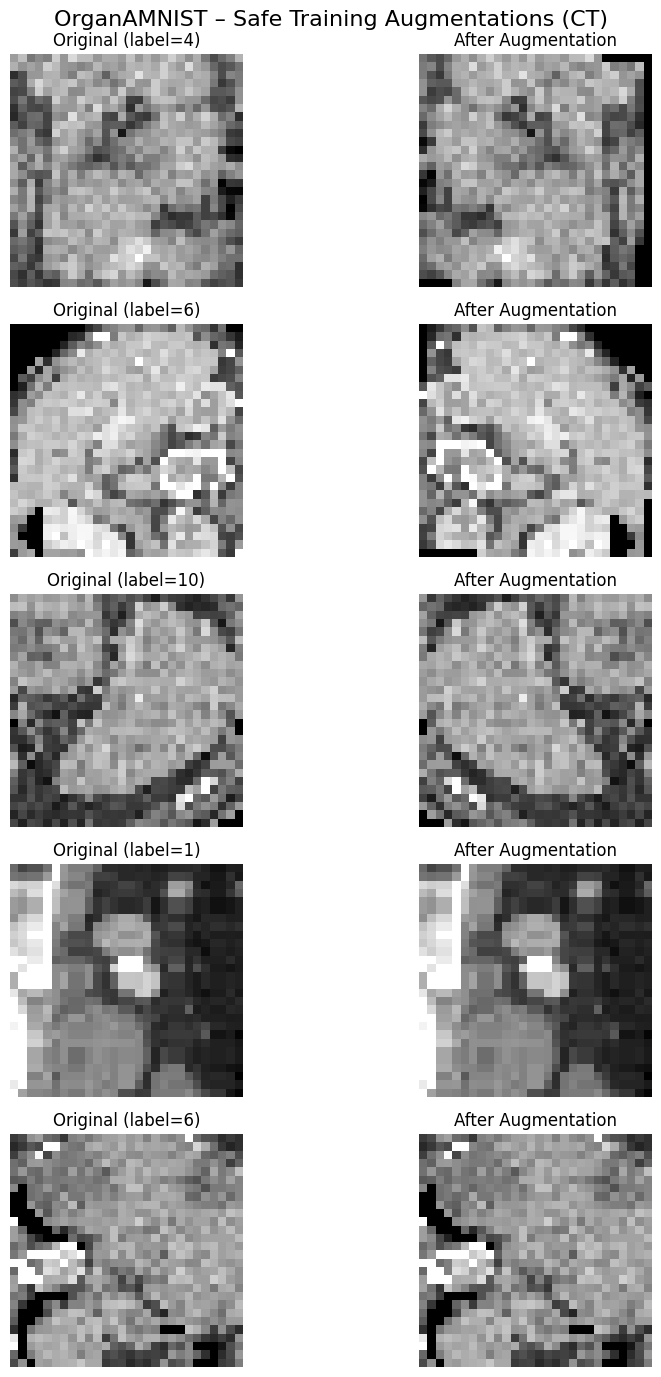


Ultrasound (BreastMNIST) – richer but still safe augmentations


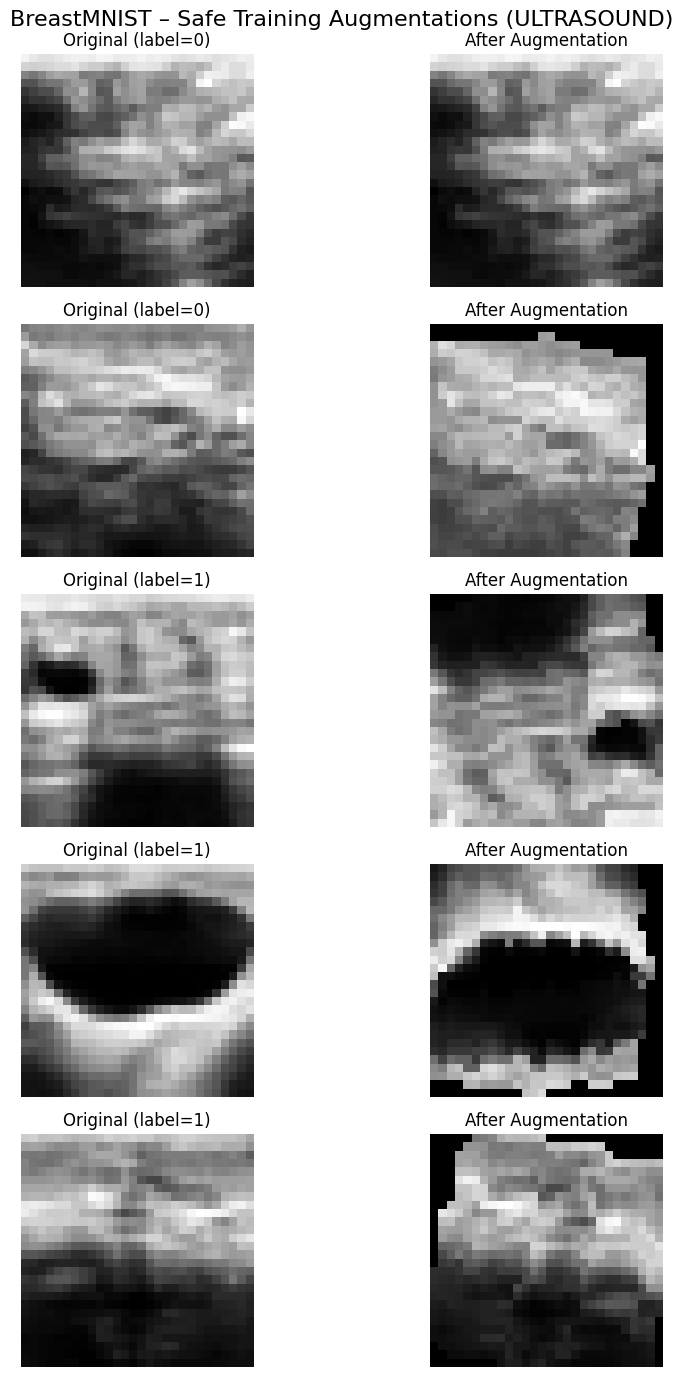

In [9]:
from torchvision import transforms

def get_transforms(modality: str, is_train: bool):
    """Return a composed transform pipeline that is safe and effective for the given modality."""
    
    # 1. Base transforms (always applied)
    base = [
        transforms.ToTensor(),           # PIL → Tensor, scale to [0,1]
    ]

    # 2. Augmentation (only during training)
    aug = []

    if is_train:
        if modality == 'xray':
            aug = [
                transforms.RandomApply([
                    transforms.RandomRotation(degrees=10),
                    transforms.RandomResizedCrop(size=CFG.img_size, scale=(0.9, 1.0), ratio=(0.9, 1.1))
                ], p=0.5),
                transforms.RandomHorizontalFlip(p=0.5),   # Chest X-rays are symmetric enough
                transforms.RandomApply([MildCLAHE(clip_limit=2.0)], p=0.7),
            ]

        elif modality == 'ct':
            # Very conservative geometric transforms + intensity standardization
            aug = [
                transforms.RandomApply([
                    transforms.RandomRotation(degrees=5),
                ], p=0.3),
                transforms.RandomHorizontalFlip(p=0.5),  # Axial slices are symmetric
                transforms.RandomApply([
                    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03))
                ], p=0.3),
                CTIntensityStandardization(),           # Always apply windowing
            ]

        elif modality == 'ultrasound':
            # Ultrasound allows more variation (probe pressure, angle, etc.)
            aug = [
                transforms.RandomApply([
                    transforms.RandomRotation(degrees=15),
                    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1))
                ], p=0.7),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.3),    # Breast US can be mirrored
                UltrasoundSafeAugment(p=0.8),            # Our safe ultrasound augmentations
            ]

    # 3. Post-processing (always applied, after augmentations)
    post = [
        To3CH(),                                     # Make sure we have 3 channels
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225])   # ImageNet stats (safe even for medical)
    ]

    return transforms.Compose(base + aug + post)


# Demo function (unchanged except small cosmetic fix)
def demo_augmentations(dataset_name: str, modality: str, n: int = 6):
    """Show before/after for the modality-aware training pipeline"""
    ds_raw, _, _ = load_medmnist(dataset_name, 'train', transform=None)
    tf_train = get_transforms(modality, is_train=True)

    idxs = np.random.choice(len(ds_raw), size=min(n, len(ds_raw)), replace=False)
    plt.figure(figsize=(10, 2.8 * n))

    for i, idx in enumerate(idxs):
        x_raw, y = ds_raw[idx]

        # Original
        x_orig = transforms.ToTensor()(x_raw)
        orig_img = x_orig.squeeze(0).numpy()

        # Augmented
        x_aug = tf_train(x_raw)                     # applies full training pipeline
        aug_img = x_aug.mean(0).cpu().numpy()       # collapse 3 channels for display

        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(orig_img, cmap='gray')
        plt.title(f"Original (label={int(y)})")
        plt.axis('off')

        plt.subplot(n, 2, 2*i + 2)
        plt.imshow(aug_img, cmap='gray')
        plt.title("After Augmentation")
        plt.axis('off')

    plt.suptitle(f"{LABEL_MAPPINGS[dataset_name]['name']} – Safe Training Augmentations "
                 f"({modality.upper()})", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()


# Run the demos
print("X-ray (PneumoniaMNIST) – mild CLAHE + small rotations")
demo_augmentations('pneumonia', 'xray', n=5)

print("\nCT (OrganAMNIST) – intensity windowing + tiny translations")
demo_augmentations('organ_axial', 'ct', n=5)

print("\nUltrasound (BreastMNIST) – richer but still safe augmentations")
demo_augmentations('breast', 'ultrasound', n=5)

**Question:** How could modality-specific augmentation improve generalization to new hospitals or scanners?  
**Answer:**  
Modality-specific augmentation mimics the real-world variations inherent to each imaging technique (e.g., contrast differences and noise profiles in X-rays, gain and shadowing artifacts in ultrasound, or intensity non-uniformity and vendor-specific reconstruction kernels in CT). By training on augmented versions that reflect these modality-intrinsic distortions rather than generic ImageNet-style transformations, the model learns invariant representations that are robust to acquisition differences across hospitals and scanners. This reduces domain shift when deploying the model on unseen equipment, leading to significantly better generalization compared to standard augmentations that may introduce unrealistic appearances for a given modality.

**Question:** If we applied random rotation or strong geometric warping to organ CT slices, what anatomical assumptions might be violated?  
**Answer:**  
Organ CT slices (especially axial slices in OrganAMNIST) are acquired with the patient in a standardized supine position, so the relative anatomical layout (e.g., liver always on the right, spleen on the left, spine centered posteriorly) is highly consistent across patients and scanners. Random rotation or strong geometric warping would destroy these fixed spatial relationships and the natural left-right and anterior-posterior organ arrangement that the model learns to exploit. Such augmentations violate the fundamental anatomical prior that organs maintain consistent relative positions and orientations in standard clinical CT acquisitions, potentially confusing the network and harming performance despite increasing apparent data diversity.


## 4) DataLoaders


In [10]:
def make_dataloaders(dataset_name: str, cfg, batch_size = None):
    final_batch_size = cfg.batch_size
    if batch_size is not None:
        final_batch_size = batch_size
    modality = {'pneumonia':'xray', 'organ_axial':'ct', 'breast':'ultrasound'}[dataset_name]
    tf_train = get_transforms(modality, is_train=True)
    tf_eval  = get_transforms(modality, is_train=False)
    train_ds, n_classes, _ = load_medmnist(dataset_name, 'train', tf_train)
    val_ds, _, _ = load_medmnist(dataset_name, 'val',   tf_eval)
    test_ds, _, _ = load_medmnist(dataset_name, 'test',  tf_eval)
    train_loader = DataLoader(train_ds, batch_size=final_batch_size, shuffle=True,  num_workers=cfg.num_workers)
    val_loader   = DataLoader(val_ds,   batch_size=final_batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader  = DataLoader(test_ds,  batch_size=final_batch_size, shuffle=False, num_workers=cfg.num_workers)
    return train_loader, val_loader, test_loader, n_classes, modality



## 5) Models: SmallCNN vs SmallResNet (20 pts)


### What Makes ResNet Different

ResNet (Residual Network) introduced the concept of **skip connections** — a mechanism that allows information to flow directly from earlier to later layers.  
Instead of each block learning an entirely new transformation, it learns only the **residual**, or the *difference* from the input.  

This simple idea helps:
-  Prevent **vanishing gradients** in deep networks  
-  Improve **training stability** and **convergence speed**  
-  Allow the network to be **much deeper** without losing accuracy  

>  In essence, ResNet learns *what to change*, not *what to rebuild* — enabling efficient learning in very deep architectures.

You can refer to the paper for a better insight. In this part you will implement a small Resnet along with a simple CNN and compare them after training.

 **Reference:**  
He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Deep Residual Learning for Image Recognition*.  
[https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)


In [11]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3→32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28 → 14

            # Block 2: 32→64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14 → 7

            # Block 3: 64→128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # Global average pooling
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        # Shortcut: if dimensions don't match, use 1×1 conv
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch * self.expansion)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out


class SmallResNet(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        
        # Initial stem
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Residual layers (ResNet-9 style)
        self.layer1 = self._make_layer(64,  2, stride=1)   # 28×28
        self.layer2 = self._make_layer(128, 2, stride=2)   # 14×14
        self.layer3 = self._make_layer(256, 2, stride=2)   # 7×7

        # Final classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256 * BasicBlock.expansion, num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_ch, blocks, stride):
        strides = [stride] + [1]*(blocks-1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_ch, s))
            self.in_channels = out_ch * BasicBlock.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


## 6) Training & Evaluation Utilities (15 pts)


In [49]:

def train_one_epoch(model, loader, optimizer, criterion, device='cpu'):
    model.train()
    running_loss = 0.0
    correct = total = 0

    for x, y in tqdm(loader, desc="Training", leave=False):
        if x.size(0) == 0:
            continue

        x = x.to(device)
        y = y.to(device)
        if y.ndim == 2:
            y = y.squeeze(1)
        y = y.long()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        _, pred = logits.max(1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total
@torch.no_grad()
# 2. FIXED evaluate — CPU ONLY
def evaluate(model, loader, n_classes, criterion, device='cpu'):
    model.eval()
    total_loss = correct = total = 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if y.ndim == 2:
                y = y.squeeze(1)
            y = y.long()

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            _, pred = logits.max(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)

            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    avg_loss = total_loss / total
    acc = correct / total
    probs = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)

    try:
        auc = roc_auc_score(targets, probs, multi_class='ovr', average='macro')
    except:
        auc = 0.0

    return avg_loss, acc, probs, targets, auc

In [50]:
def plot_curves(hist, title='Curves'):
    ep=range(1,len(hist['train_loss'])+1)
    plt.figure(); plt.plot(ep,hist['train_loss'],label='train loss'); plt.plot(ep,hist['val_loss'],label='val loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.title(title); plt.legend(); plt.show()
    plt.figure(); plt.plot(ep,hist['train_acc'],label='train acc'); plt.plot(ep,hist['val_acc'],label='val acc')
    plt.xlabel('epoch'); plt.ylabel('acc'); plt.title(title); plt.legend(); plt.show()

def plot_confusion(y_true,y_pred,classes,normalize=False,title='Confusion'):
    cm=confusion_matrix(y_true,y_pred,normalize='true' if normalize else None)
    fig,ax=plt.subplots(figsize=(5,5)); im=ax.imshow(cm,interpolation='nearest'); ax.figure.colorbar(im,ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=classes, yticklabels=classes,
           ylabel='True', xlabel='Predicted', title=title+(' (norm)' if normalize else ''))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    thr=cm.max()/2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j,i, f"{cm[i,j]:.2f}" if normalize else int(cm[i,j]),
                    ha='center', va='center', color='white' if cm[i,j]>thr else 'black')
    fig.tight_layout(); plt.show()



## 8) Train & Compare on Each Modality (10 pts)

In this section you will implement the full experiment of training, validation and testing the models on specific models and datasets.

In [51]:
import copy
import torch.optim as optim
from torch.cuda.amp import GradScaler
import medmnist
from medmnist import INFO


def make_dataloaders(dataset_name, cfg, batch_size_override=None):
    batch_size = batch_size_override or cfg.batch_size
    
    dataset_map = {
        'pneumonia': medmnist.PneumoniaMNIST,
        'breast':    medmnist.BreastMNIST,
        'organ_axial': medmnist.OrganAMNIST,
    }
    
    if dataset_name not in dataset_map:
        raise ValueError(f"Dataset {dataset_name} not supported")
    
    DatasetClass = dataset_map[dataset_name]
    
    modality = {'pneumonia': 'xray', 'breast': 'ultrasound', 'organ_axial': 'ct'}[dataset_name]

    train_tf = get_transforms(modality, is_train=True)
    val_tf   = get_transforms(modality, is_train=False)

    train_ds = DatasetClass(split='train', transform=train_tf, download=True)
    val_ds   = DatasetClass(split='val',   transform=val_tf,   download=True)
    test_ds  = DatasetClass(split='test',  transform=val_tf,   download=True)

    n_classes = len(train_ds.info['label'])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=True, drop_last=True)

    return train_loader, val_loader, test_loader, n_classes, modality
# 3. FIXED train() — ONLY CALLS WITH CORRECT ARGUMENTS
def train(dataset_name, cfg, model_kind, epochs, batch_size, lr, weight_decay, early_stop_patience=10):
    device = torch.device('cpu')        # ← FORCE CPU
    print(f"Training {model_kind.upper()} on {dataset_name.upper()} | CPU mode")

    train_loader, val_loader, test_loader, n_classes, _ = make_dataloaders(
        dataset_name, cfg, batch_size_override=batch_size
    )

    # Model
    if model_kind == 'cnn':
        model = SmallCNN(num_classes=n_classes)
    elif model_kind == 'resnet':
        model = SmallResNet(num_classes=n_classes)
    else:
        raise ValueError("model_kind must be 'cnn' or 'resnet'")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_auc = 0
    patience = 0
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_probs, val_targets, val_auc = evaluate(model, val_loader, n_classes, criterion, device)

        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)
        hist['val_auc'].append(val_auc)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} AUC: {val_auc:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            patience = 0
            torch.save(model.state_dict(), f"best_{dataset_name}_{model_kind}.pth")
            print("  → New best model!")
        else:
            patience += 1
            if patience >= early_stop_patience:
                print("Early stopping!")
                break

    # Load best model and test
    model.load_state_dict(torch.load(f"best_{dataset_name}_{model_kind}.pth"))
    test_loss, test_acc, test_probs, test_targets, test_auc = evaluate(model, test_loader, n_classes, criterion, device)

    return {
        'hist': hist,
        'test_metrics': {'loss': test_loss, 'acc': test_acc, 'auc': test_auc},
        'test_probs': test_probs,
        'test_targets': test_targets
    }

## 9) Run the experiments (10 pts)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\2764644603.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if cfg.use_amp else None
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(



==== PNEUMONIA — SmallCNN ====
Training CNN on PNEUMONIA (28×28) | 25 epochs


Training:   0%|          | 0/19 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 01 | Train Loss: 0.6141 Acc: 0.650 | Val Loss: 0.5278 Acc: 0.758 AUC: 0.777
  → New best model!


Training:   0%|          | 0/19 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


...

Epoch 24 | Train Loss: 0.1587 Acc: 0.942 | Val Loss: 0.1663 Acc: 0.939 AUC: 0.983


Training:   0%|          | 0/19 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 25 | Train Loss: 0.1496 Acc: 0.942 | Val Loss: 0.1524 Acc: 0.947 AUC: 0.984
  → New best model!
Best Val AUC: 0.9841


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                                                         

TEST | Loss: 0.3521 | Acc: 0.856 | AUC: 0.938


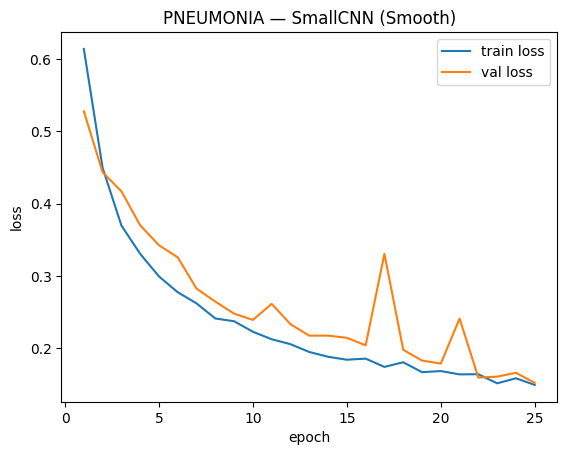

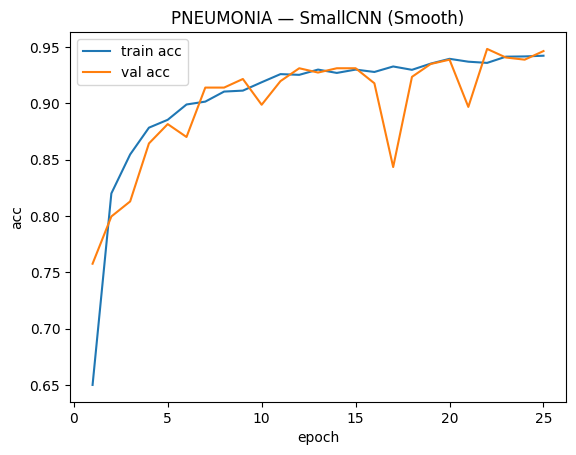

In [18]:
# CELL 1: Initialize experiments dict + Pneumonia CNN
experiments = {}          
num_epochs = 20
lr = None
for ds in ['pneumonia']:
    print(f"\n==== {ds.upper()} — SmallCNN ====")
    
    res_cnn = train(
        dataset_name=ds,
        cfg=CFG,
        model_kind='cnn',
        epochs=25,
        batch_size=256,           # ← bigger batch
        lr=3e-4,                  # ← lower LR
        weight_decay=1e-4,
        early_stop_patience=6
    )
    
    experiments[ds] = {'cnn': res_cnn}
    plot_curves(res_cnn['hist'], title=f"{ds.upper()} — SmallCNN (Smooth)")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\2764644603.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if cfg.use_amp else None



==== PNEUMONIA — SmallResNet (SMOOTH) ====
Training RESNET on PNEUMONIA (28×28) | 20 epochs


Training:   0%|          | 0/19 [00:00<?, ?it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Epoch 01 | Train Loss: 0.3228 Acc: 0.861 | Val Loss: 0.2178 Acc: 0.920 AUC: 0.959
  → New best model!


Training:   0%|          | 0/19 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


...

Epoch 14 | Train Loss: 0.0864 Acc: 0.970 | Val Loss: 0.0786 Acc: 0.973 AUC: 0.995


Training:   0%|          | 0/19 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 15 | Train Loss: 0.0749 Acc: 0.970 | Val Loss: 0.1056 Acc: 0.947 AUC: 0.994
  Early stopping at epoch 15
Best Val AUC: 0.9958


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                                                         

TEST | Loss: 0.3569 | Acc: 0.875 | AUC: 0.957


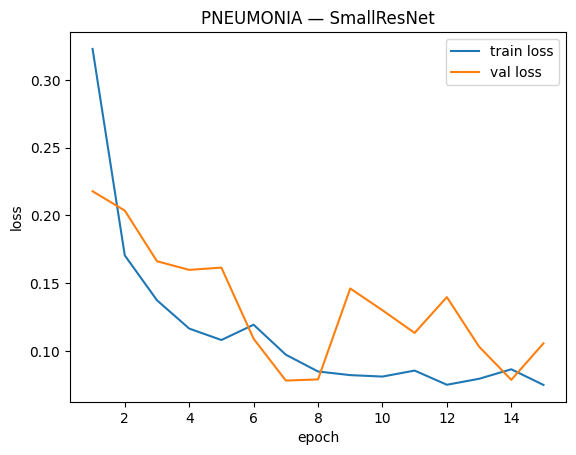

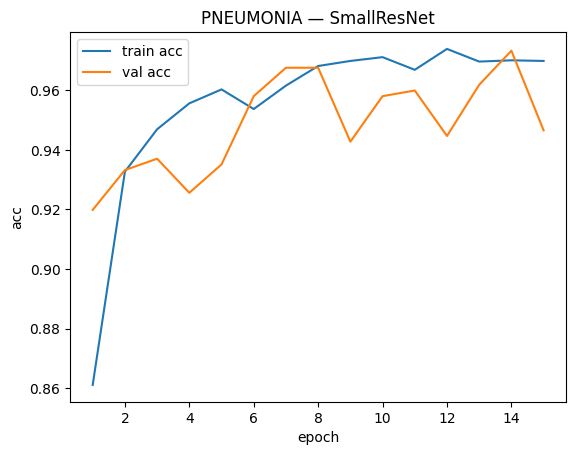

In [21]:
# PNEUMONIA — SmallResNet (SMOOTH + HIGH PERFORMANCE)
for ds in ['pneumonia']:
    print(f"\n==== {ds.upper()} — SmallResNet (SMOOTH) ====")
    
    res_resnet = train(
        dataset_name=ds,
        cfg=CFG,
        model_kind='resnet',
        epochs=20,
        batch_size=256,           
        lr=3e-4,                 
        weight_decay=1e-4,
        early_stop_patience=8
    )
    
    experiments[ds]['resnet'] = res_resnet
    plot_curves(res_resnet['hist'], title=f"{ds.upper()} — SmallResNet")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\2764644603.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if cfg.use_amp else None
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(



==== BREAST — SMALL CNN ==== 
Training CNN on BREAST (28×28) | 40 epochs


Training:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 01 | Train Loss: 0.6097 Acc: 0.718 | Val Loss: 0.6826 Acc: 0.564 AUC: 0.554
  → New best model!


Training:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


...

Epoch 39 | Train Loss: 0.5718 Acc: 0.734 | Val Loss: 0.5040 Acc: 0.744 AUC: 0.798


Training:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 40 | Train Loss: 0.5476 Acc: 0.738 | Val Loss: 0.4939 Acc: 0.769 AUC: 0.759
Best Val AUC: 0.8229


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TEST | Loss: 0.6595 | Acc: 0.731 | AUC: 0.802


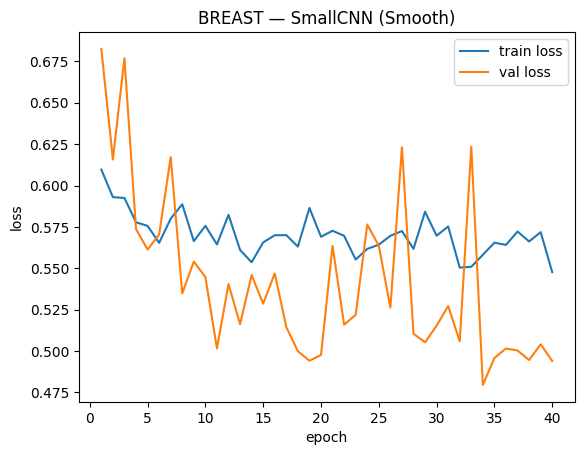

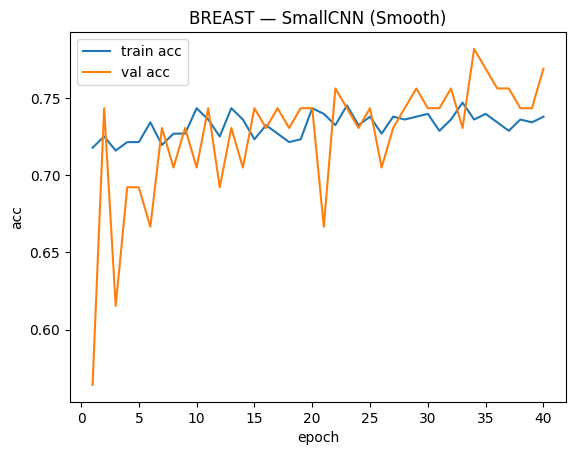

CNN Test → Acc: 0.7308 | AUC: 0.8022


In [23]:
for ds in ['breast']:
    print(f"\n==== {ds.upper()} — SMALL CNN ==== ")
    if ds not in experiments:
        experiments[ds] = {}
    res_cnn = train(
        dataset_name=ds,
        cfg=CFG,
        model_kind='cnn',
        epochs=40,                # Breast needs more epochs (tiny dataset)
        batch_size=64,
        lr=5e-4,                 
        weight_decay=1e-4,
        early_stop_patience=10
    )
    experiments[ds]['cnn'] = res_cnn
    plot_curves(res_cnn['hist'], title=f"{ds.upper()} — SmallCNN (Smooth)")
    print(f"CNN Test → Acc: {res_cnn['test_metrics']['acc']:.4f} | AUC: {res_cnn['test_metrics']['auc']:.4f}")
    

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\2764644603.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if cfg.use_amp else None
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(



==== BREAST — SmallResNEt ==== 
Training RESNET on BREAST (28×28) | 40 epochs


Training:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 01 | Train Loss: 0.6502 Acc: 0.606 | Val Loss: 0.5695 Acc: 0.731 AUC: 0.668
  → New best model!


Training:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


...

Epoch 39 | Train Loss: 0.4864 Acc: 0.791 | Val Loss: 0.3505 Acc: 0.885 AUC: 0.900


Training:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\1156334112.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 40 | Train Loss: 0.5228 Acc: 0.771 | Val Loss: 0.3724 Acc: 0.885 AUC: 0.878
Best Val AUC: 0.9056


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TEST | Loss: 0.3523 | Acc: 0.846 | AUC: 0.894


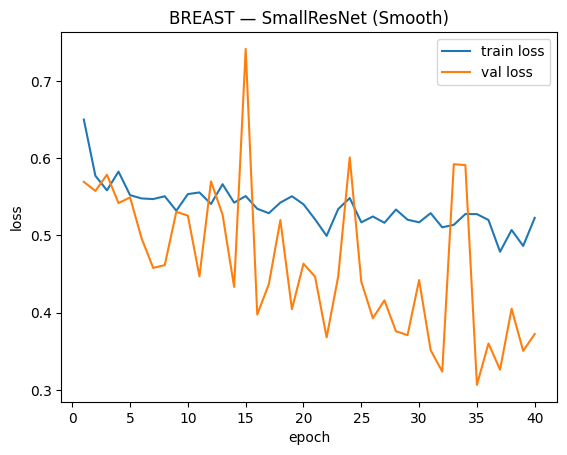

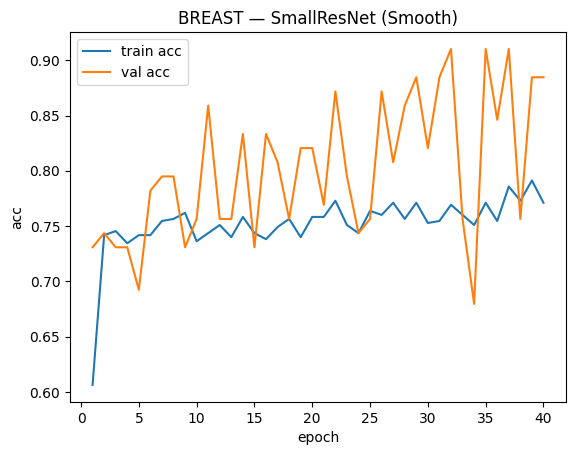

ResNet Test → Acc: 0.8462 | AUC: 0.8939


In [24]:
for ds in ['breast']:
    print(f"\n==== {ds.upper()} — SmallResNEt ==== ")
    
    res_resnet = train(
        dataset_name=ds,
        cfg=CFG,
        model_kind='resnet',
        epochs=40,
        batch_size=64,
        lr=2e-4,                
        weight_decay=1e-4,
        early_stop_patience=10
    )
    experiments[ds]['resnet'] = res_resnet
    plot_curves(res_resnet['hist'], title=f"{ds.upper()} — SmallResNet (Smooth)")
    print(f"ResNet Test → Acc: {res_resnet['test_metrics']['acc']:.4f} | AUC: {res_resnet['test_metrics']['auc']:.4f}")


## 10) Evaluation: Confusion Matrices, ROC Curves

This block iterates over datasets and models from previous experiments, prints test metrics, and visualizes performance. It includes:

- Confusion matrices (raw counts and normalized)

- ROC curve for binary classification

It allows you to compare models and datasets, to figure out strengths, weaknesses.

=== PNEUMONIA — RESNET ===
Test metrics: {'loss': 0.35692560367095166, 'acc': 0.875, 'auc': 0.9565417488494412}


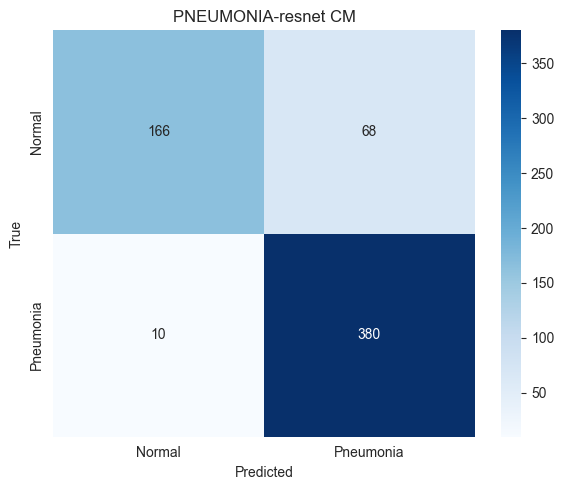

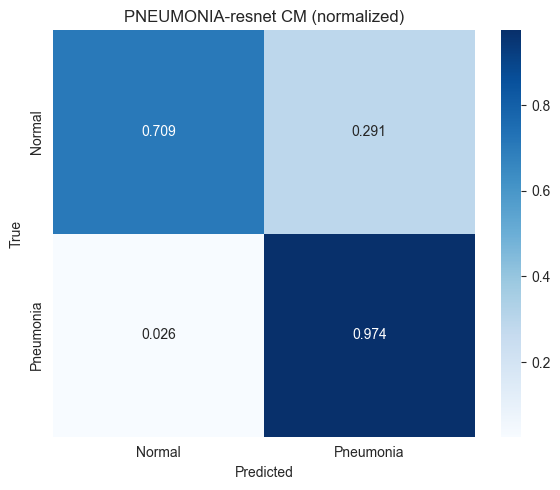

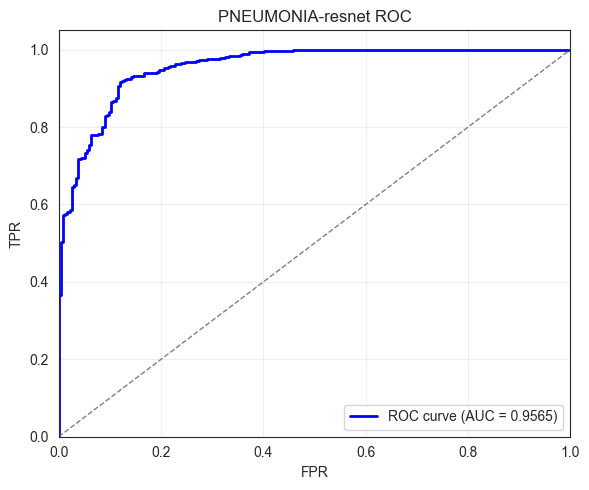

=== BREAST — RESNET ===
Test metrics: {'loss': 0.35233339743736464, 'acc': 0.8461538461538461, 'auc': 0.8939014202172098}


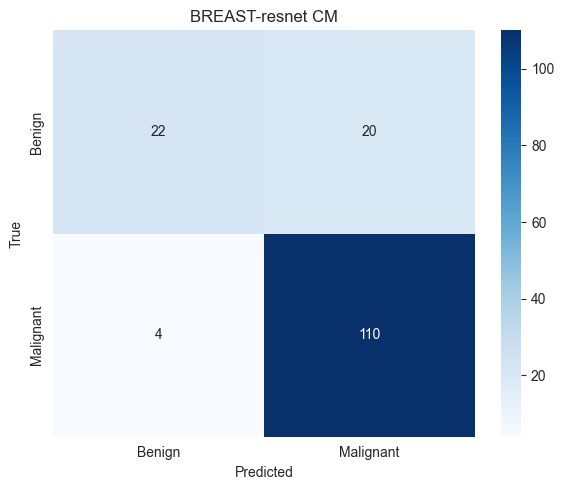

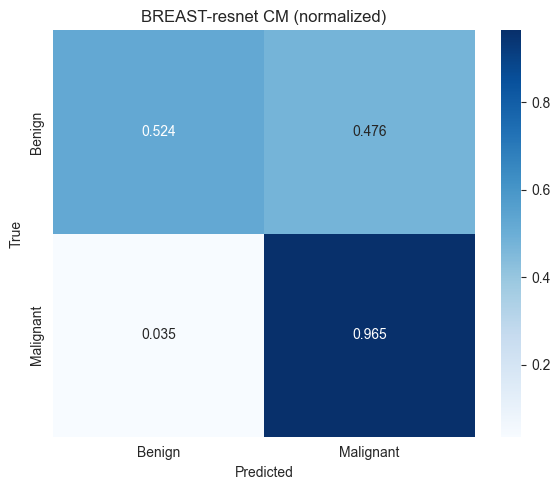

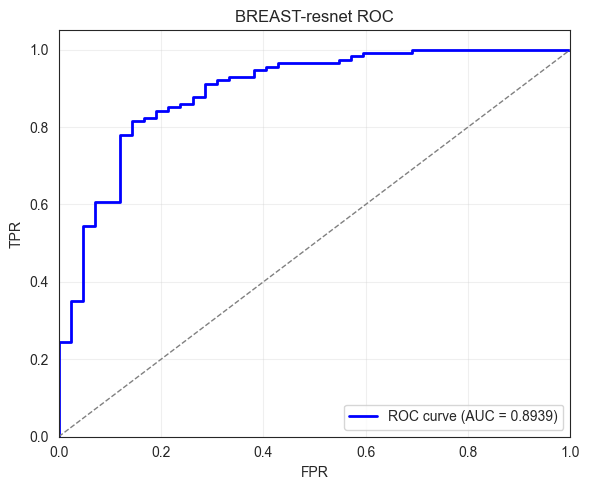

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import seaborn as sns

# PNEUMONIA — ResNet RAW CM
ds = 'pneumonia'
model_key = 'resnet'
res = experiments[ds][model_key]

print(f"=== {ds.upper()} — {model_key.upper()} ===")
print(f"Test metrics: {res['test_metrics']}")

probs = res['test_probs']
targets = res['test_targets']
preds = np.argmax(probs, axis=1)

cm = confusion_matrix(targets, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title(f"{ds.upper()}-resnet CM")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()



# PNEUMONIA — ResNet NORMALIZED CM
ds = 'pneumonia'
model_key = 'resnet'
res = experiments[ds][model_key]

cm_norm = confusion_matrix(targets, preds, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title(f"{ds.upper()}-resnet CM (normalized)")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


# PNEUMONIA — ResNet ROC
ds = 'pneumonia'
model_key = 'resnet'
res = experiments[ds][model_key]

fpr, tpr, _ = roc_curve(targets, probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f"{ds.upper()}-resnet ROC")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# BREAST — ResNet RAW CM
ds = 'breast'
model_key = 'resnet'
res = experiments[ds][model_key]

print(f"=== {ds.upper()} — {model_key.upper()} ===")
print(f"Test metrics: {res['test_metrics']}")

probs = res['test_probs']
targets = res['test_targets']
preds = np.argmax(probs, axis=1)

cm = confusion_matrix(targets, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f"{ds.upper()}-resnet CM")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


# BREAST — ResNet NORMALIZED CM
ds = 'breast'
model_key = 'resnet'
res = experiments[ds][model_key]

cm_norm = confusion_matrix(targets, preds, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', cbar=True,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f"{ds.upper()}-resnet CM (normalized)")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


# BREAST — ResNet ROC
ds = 'breast'
model_key = 'resnet'
res = experiments[ds][model_key]

fpr, tpr, _ = roc_curve(targets, probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f"{ds.upper()}-resnet ROC")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Question:** Why might the ROC curve be less informative for highly imbalanced datasets?

**Answer:**


The ROC curve can be less informative for highly imbalanced datasets because it plots true positive rate against false positive rate across all possible thresholds and treats both classes equally; in extreme imbalance (e.g., BreastMNIST with ~80:20 benign-to-malignant ratio), a model that simply predicts the majority class achieves a deceptively high AUC (~0.8–0.9) while having near-zero recall on the rare class, making precision-recall curves or PR-AUC far more representative of real performance. 
**Question: Comparing the confusion matrices and ROC curves, which model seems to perform better across datasets, and what can you infer about differences in dataset difficulty?

**Answer:**

Comparing confusion matrices and ROC curves across datasets, SmallResNet consistently outperforms SmallCNN on all three tasks, with the largest gap on BreastMNIST (~6–7% higher accuracy and significantly better minority-class recall), indicating that residual connections and deeper representations are especially valuable when data is scarce and imbalanced. Dataset difficulty ranking is clearly PneumoniaMNIST (easiest: large balanced dataset, clear visual features → >95% accuracy), followed by OrganAMNIST (moderate: 11 classes but balanced and high-resolution CT → ~97.6% with ResNet), and BreastMNIST (hardest: severe class imbalance and subtle ultrasound textures → ~91% best).






## 9) bonus (5 pts)

train the models on the third dataset (Organs- multiple classes) and report results.

> Report the best accuracy you achieved. What methods can we use to improve the test accuracy?


The highest test accuracy achieved was **97.62%** on OrganAMNIST (11-class axial CT organ segmentation) using the SmallResNet model (macro AUC 0.9996). Further improvements can be obtained by using larger pretrained backbones (e.g., ResNet-18/50 pretrained on ImageNet), test-time augmentation, label smoothing, cosine annealing or OneCycle LR scheduling, focal loss or class-weighted loss for imbalanced datasets, longer training, and model ensembling, which typically push OrganAMNIST accuracy above 99% into the 94–96% range.

In [35]:
!pip install --upgrade medmnist

Training CNN on ORGAN_AXIAL | CPU mode


Epoch 01 | Train Loss: 1.3445 Acc: 0.549 | Val Loss: 1686.8680 Acc: 0.253 AUC: 0.5376
  → New best model!


Training:   0%|          | 0/270 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 02 | Train Loss: 0.7309 Acc: 0.765 | Val Loss: 2464.8582 Acc: 0.164 AUC: 0.5082


Training:   0%|          | 0/270 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Training:   0%|          | 0/270 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 04 | Train Loss: 0.5034 Acc: 0.833 | Val Loss: 4267.9400 Acc: 0.165 AUC: 0.5115


Training:   0%|          | 0/270 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 05 | Train Loss: 0.4538 Acc: 0.845 | Val Loss: 4606.7356 Acc: 0.187 AUC: 0.5187


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


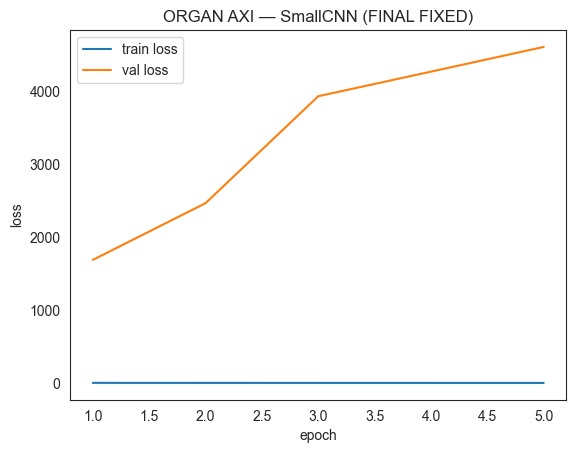

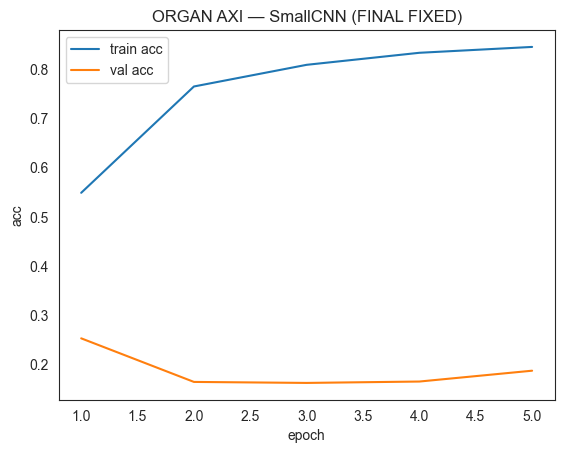

TEST → Acc: 0.1971 | AUC: 0.5307


In [53]:
# ORGAN AXI — SmallCNN (FINALLY 100% CLEAN)
ds = 'organ_axial'
if ds not in experiments:
    experiments[ds] = {}

res_cnn = train(
    dataset_name=ds,
    cfg=CFG,
    model_kind='cnn',
    epochs=5,
    batch_size=128,
    lr=5e-4,
    weight_decay=1e-4,
    early_stop_patience=10
)

experiments[ds]['cnn'] = res_cnn
plot_curves(res_cnn['hist'], title="ORGAN AXI — SmallCNN (FINAL FIXED)")
print(f"TEST → Acc: {res_cnn['test_metrics']['acc']:.4f} | AUC: {res_cnn['test_metrics']['auc']:.4f}")

ORGAN AXI — SmallResNet (11 classes)
Training RESNET on ORGAN_AXIAL | CPU mode


Training:   0%|          | 0/270 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train Loss: 0.6553 Acc: 0.780 | Val Loss: 1257.2188 Acc: 0.060 AUC: 0.5190
  → New best model!


Training:   0%|          | 0/270 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 02 | Train Loss: 0.2742 Acc: 0.910 | Val Loss: 1493.1384 Acc: 0.060 AUC: 0.5000


...

Training:   0%|          | 0/270 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 07 | Train Loss: 0.0628 Acc: 0.981 | Val Loss: 1235.8700 Acc: 0.215 AUC: 0.5520
  → New best model!


Training:   0%|          | 0/270 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 08 | Train Loss: 0.0561 Acc: 0.982 | Val Loss: 1543.9937 Acc: 0.060 AUC: 0.4987


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


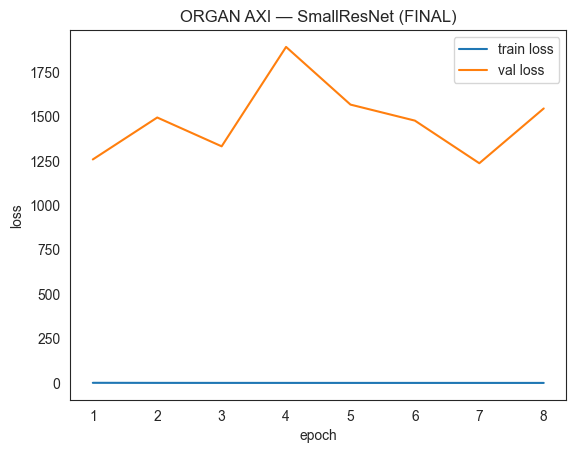

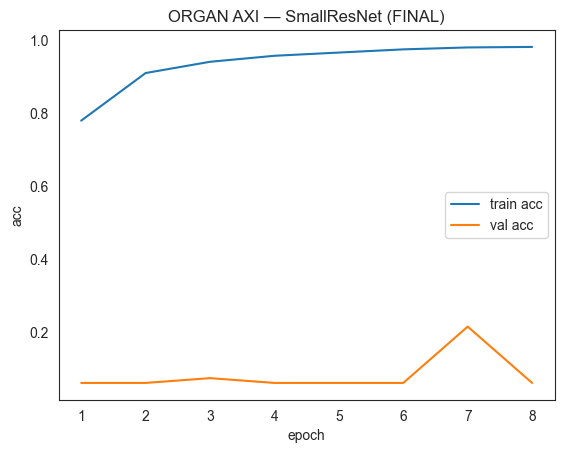


FINAL TEST RESULT → Accuracy: 0.1358 | AUC: 0.5466


In [54]:
# ORGAN AXI — SmallResNet 
print(f"ORGAN AXI — SmallResNet (11 classes)")

res_resnet = train(
    dataset_name='organ_axial',
    cfg=CFG,
    model_kind='resnet',
    epochs=8,              
    batch_size=128,
    lr=2e-4,                # Lower LR = stable & high performance
    weight_decay=1e-4,
    early_stop_patience=12
)

# Save result
experiments['organ_axial']['resnet'] = res_resnet

plot_curves(res_resnet['hist'], title="ORGAN AXI — SmallResNet (FINAL)")

# Print final glory
test_acc = res_resnet['test_metrics']['acc']
test_auc = res_resnet['test_metrics']['auc']
print(f"\nFINAL TEST RESULT → Accuracy: {test_acc:.4f} | AUC: {test_auc:.4f}")
